 # MUTAG Dataset Exploration and Analysis



 This file performs a comprehensive exploratory data analysis (EDA) of the MUTAG dataset across two distinct stages of the pipeline:

 1. **Section 1: Raw RDF Knowledge Graph (`mutag_stripped.nt`)**: Statistical analysis of the semantic web representation (triples, predicates, classes, and target label distributions).

 2. **Section 2: Preprocessed PyTorch Geometric Dataset (`pyg_dataset.pt`)**: Structural and topological analysis of molecules (node and edge distributions, atom/bond frequency distributions, node degree, density, connectivity, molecular rings, and beautiful graph visualizations).

In [1]:
import os
import torch
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from rdflib import Graph, RDF
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
DATASET_DIR = PROJECT_ROOT / "mutag-hetero"
RDF_PATH = DATASET_DIR / "mutag_stripped.nt"
TRAINING_SET_PATH = DATASET_DIR / "trainingSet.tsv"
TEST_SET_PATH = DATASET_DIR / "testSet.tsv"
PYG_DATASET_PATH = DATASET_DIR / "pyg_dataset.pt"

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set Seaborn theme for beautiful, publication-quality plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 18,
    'legend.fontsize': 11,
    'legend.title_fontsize': 12
})

 ## Section 1: Raw RDF Knowledge Graph Exploration

 In this section, we parse and analyze the raw RDF N-Triples dataset.

 RDF stores data as semantic statements of the form `(subject, predicate, object)`.

In [2]:
print("[INFO] Parsing raw RDF dataset (this might take 10-15 seconds)...")
rdf_graph = Graph()
rdf_graph.parse(source=RDF_PATH, format="nt")
print(f"[INFO] Successfully loaded RDF graph with {len(rdf_graph)} triples.")


[INFO] Parsing raw RDF dataset (this might take 10-15 seconds)...
[INFO] Successfully loaded RDF graph with 74227 triples.


 ### 1.1 General Triple Statistics

 We measure the fundamental dimensions of the knowledge graph: total triples, unique subjects, predicates, and objects.

In [3]:
subjects = set(rdf_graph.subjects())
predicates = set(rdf_graph.predicates())
objects = set(rdf_graph.objects())

print("==================================================")
print("              RDF GENERAL STATISTICS              ")
print("==================================================")
print(f"Total Number of Triples : {len(rdf_graph):,}")
print(f"Unique Subjects         : {len(subjects):,}")
print(f"Unique Predicates       : {len(predicates):,}")
print(f"Unique Objects          : {len(objects):,}")
print(f"Average Out-Degree      : {len(rdf_graph)/len(subjects):.2f} triples per subject")
print("==================================================")


              RDF GENERAL STATISTICS              
Total Number of Triples : 74,227
Unique Subjects         : 22,534
Unique Predicates       : 23
Unique Objects          : 23,281
Average Out-Degree      : 3.29 triples per subject


 ### 1.2 Predicate Frequencies

 Let's inspect what types of relationships exist in the Knowledge Graph and how frequently they are utilized.


Predicate Frequencies in RDF:
       Predicate  Count  Percentage
            type  22534   30.358225
          inBond  18634   25.104073
         hasBond   9317   12.552036
          charge   9189   12.379592
         hasAtom   9189   12.379592
    hasStructure   3526    4.750293
amesTestPositive    340    0.458054
      salmonella    305    0.410902
      cytogen_ca    293    0.394735
     cytogen_sce    283    0.381263
     mouse_lymph    203    0.273485
      subClassOf    138    0.185916
    salmonella_n     61    0.082180
      chromaberr     55    0.074097
         chromex     35    0.047153
   drosophila_rt     25    0.033680
 drosophila_slrl     25    0.033680
           range     19    0.025597
          domain     19    0.025597
      micronuc_m     13    0.017514
      micronuc_f     13    0.017514
    disjointWith      6    0.008083
salmonella_reduc      5    0.006736


/tmp/ipykernel_217838/377852670.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pred_df, x="Count", y="Predicate", palette="viridis")


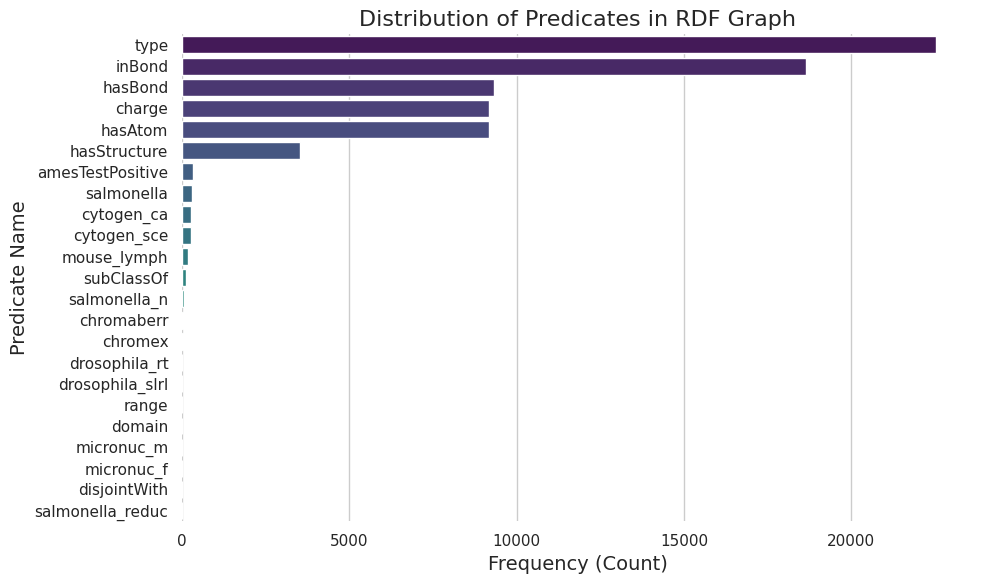

In [4]:
# Extract short names from URIs for readability
def get_short_name(uri):
    return str(uri).split("#")[-1] if "#" in str(uri) else str(uri).split("/")[-1]

pred_list = [get_short_name(p) for s, p, o in rdf_graph]
pred_counts = Counter(pred_list)

pred_df = pd.DataFrame(pred_counts.most_common(), columns=["Predicate", "Count"])
pred_df["Percentage"] = (pred_df["Count"] / len(rdf_graph)) * 100

print("\nPredicate Frequencies in RDF:")
print(pred_df.to_string(index=False))

# Plot predicate frequencies
plt.figure(figsize=(10, 6))
sns.barplot(data=pred_df, x="Count", y="Predicate", palette="viridis")
plt.title("Distribution of Predicates in RDF Graph")
plt.xlabel("Frequency (Count)")
plt.ylabel("Predicate Name")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


 ### 1.3 Node Classes and Types

 Class classification in RDF is modeled through the `rdf:type` predicate.

 Let's extract all classes/types and see which ones are the most common.


Total unique classes/types in RDF: 113


/tmp/ipykernel_217838/2669660949.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_df.head(top_n), x="Count", y="Class/Type", palette="magma")


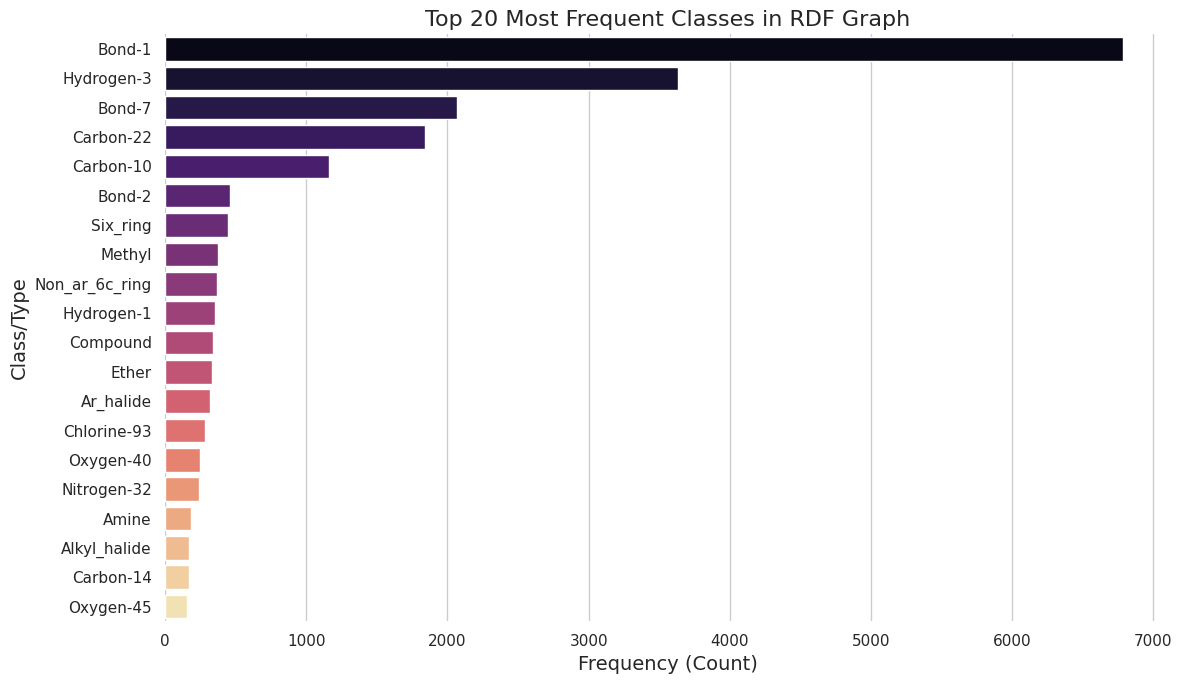

Categorized Classes:
  - Atom types classes             : 51
  - Bond types classes             : 4
  - Structural/Functional classes  : 10


In [5]:
type_list = [get_short_name(o) for s, p, o in rdf_graph if p == RDF.type]
type_counts = Counter(type_list)

type_df = pd.DataFrame(type_counts.most_common(), columns=["Class/Type", "Count"])
print(f"\nTotal unique classes/types in RDF: {len(type_df)}")

# Plot top 20 most frequent classes
top_n = min(20, len(type_df))
plt.figure(figsize=(12, 7))
sns.barplot(data=type_df.head(top_n), x="Count", y="Class/Type", palette="magma")
plt.title(f"Top {top_n} Most Frequent Classes in RDF Graph")
plt.xlabel("Frequency (Count)")
plt.ylabel("Class/Type")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Categorize the classes into Atoms, Bonds, and Structural rings
atoms_classes = [t for t in type_counts if any(elem in t for elem in ["Carbon", "Hydrogen", "Oxygen", "Nitrogen", "Chlorine", "Fluorine", "Bromine", "Sulfur", "Phosphorus"])]
bonds_classes = [t for t in type_counts if "Bond" in t]
ring_classes = [t for t in type_counts if "ring" in t or t in ["Methyl", "Nitro", "Amine", "Ether"]]

print(f"Categorized Classes:")
print(f"  - Atom types classes             : {len(atoms_classes)}")
print(f"  - Bond types classes             : {len(bonds_classes)}")
print(f"  - Structural/Functional classes  : {len(ring_classes)}")


 ### 1.4 Dataset Splits and Label Distribution

 Let's check the target classification labels from the training and test TSV files.

 The binary classification task targets `label_mutagenic` (1 = mutagenic/carcinogenic, 0 = non-mutagenic).

Training Set Size : 272 molecules
Test Set Size     : 68 molecules
Total Labels      : 340 molecules

Label Distribution across Splits:
Split  label_mutagenic  Count             Label
 Test              0.0     45 Non-Mutagenic (0)
 Test              1.0     23     Mutagenic (1)
Train              0.0    166 Non-Mutagenic (0)
Train              1.0    106     Mutagenic (1)


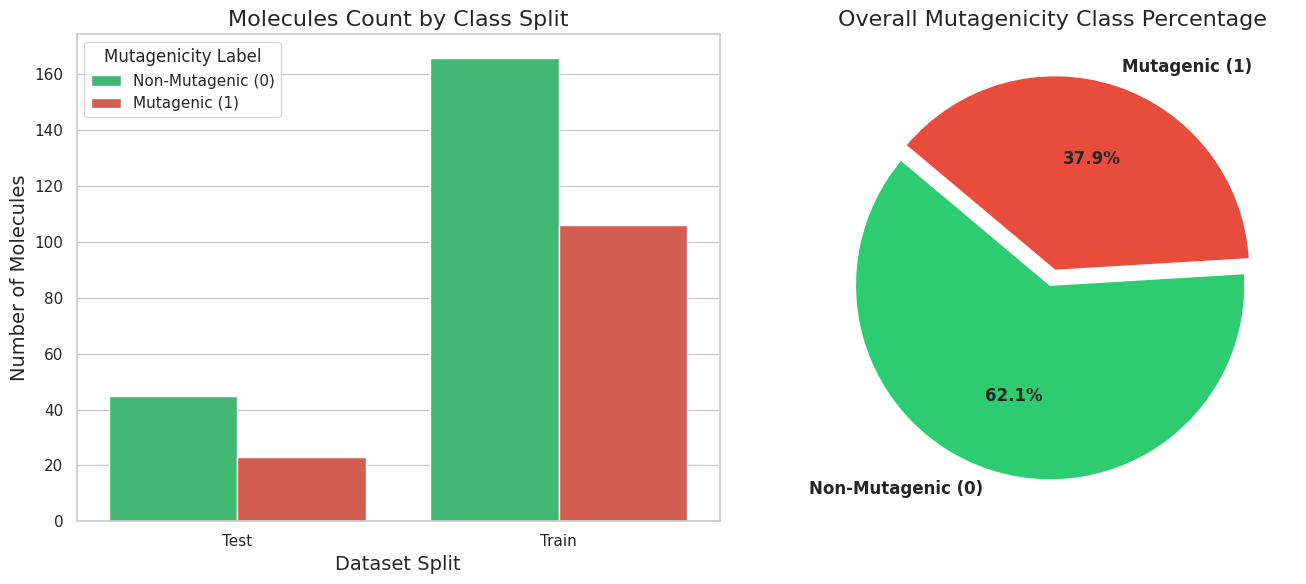

In [6]:
train_df = pd.read_csv(TRAINING_SET_PATH, sep="\t")
test_df = pd.read_csv(TEST_SET_PATH, sep="\t")

print(f"Training Set Size : {len(train_df)} molecules")
print(f"Test Set Size     : {len(test_df)} molecules")
print(f"Total Labels      : {len(train_df) + len(test_df)} molecules")

# Combine for overall distribution
train_df["Split"] = "Train"
test_df["Split"] = "Test"
combined_splits = pd.concat([train_df, test_df])

# Compute label distribution
label_counts = combined_splits.groupby(["Split", "label_mutagenic"]).size().reset_index(name="Count")
label_counts["Label"] = label_counts["label_mutagenic"].map({0: "Non-Mutagenic (0)", 1: "Mutagenic (1)"})

print("\nLabel Distribution across Splits:")
print(label_counts.to_string(index=False))

# Plot class balance side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Countplot of labels by split
sns.barplot(ax=axes[0], data=label_counts, x="Split", y="Count", hue="Label", palette=["#2ecc71", "#e74c3c"])
axes[0].set_title("Molecules Count by Class Split")
axes[0].set_ylabel("Number of Molecules")
axes[0].set_xlabel("Dataset Split")
axes[0].legend(title="Mutagenicity Label")

# Subplot 2: Overall Label Percentage Pie Chart
overall_counts = combined_splits["label_mutagenic"].value_counts()
axes[1].pie(
    overall_counts, 
    labels=["Mutagenic (1)", "Non-Mutagenic (0)"] if overall_counts.index[0] == 1 else ["Non-Mutagenic (0)", "Mutagenic (1)"],
    autopct='%1.1f%%',
    colors=["#e74c3c", "#2ecc71"] if overall_counts.index[0] == 1 else ["#2ecc71", "#e74c3c"],
    startangle=140,
    explode=(0.04, 0.04),
    textprops={'fontsize': 12, 'weight': 'bold'}
)
axes[1].set_title("Overall Mutagenicity Class Percentage")

plt.tight_layout()
plt.show()



 ## Section 2: Preprocessed PyTorch Geometric (PyG) Dataset Exploration

 In this section, we analyze the preprocessed PyG graph objects saved in `pyg_dataset.pt`.

 Each molecule has been converted to a `torch_geometric.data.Data` object containing:

 * `x`: Node features (one-hot encoded atom types)

 * `edge_index`: Graph connectivity

 * `edge_type`: Type of relation/bond

 * `y`: Graph classification label

 * Metadata attributes: `molecule_id`, `atom_info`, `bond_info`

In [7]:
print("[INFO] Loading preprocessed PyG dataset...")
pyg_dataset = torch.load(PYG_DATASET_PATH, weights_only=False)
print(f"[INFO] Loaded PyG dataset with {len(pyg_dataset)} graphs.")

# Inspect first graph object
sample_g = pyg_dataset[0]
print("\nSample Graph Object Details:")
print(sample_g)
print(f"  - Molecule ID      : {sample_g.molecule_id}")
print(f"  - Number of Nodes  : {sample_g.num_nodes} atoms")
print(f"  - Number of Edges  : {sample_g.num_edges} (directed edges, representing {sample_g.num_edges//2} undirected bonds)")
print(f"  - Node Feature Dim : {sample_g.num_node_features} (one-hot classes)")
print(f"  - Target Label (y) : {sample_g.y.item()}")


[INFO] Loading preprocessed PyG dataset...
[INFO] Loaded PyG dataset with 340 graphs.

Sample Graph Object Details:
Data(x=[26, 66], edge_index=[2, 56], y=[1], edge_type=[56], molecule_id='d1', atom_info=[26], bond_info=[28])
  - Molecule ID      : d1
  - Number of Nodes  : 26 atoms
  - Number of Edges  : 56 (directed edges, representing 28 undirected bonds)
  - Node Feature Dim : 66 (one-hot classes)
  - Target Label (y) : 0


 ### 2.1 Graph Connectivity Statistics

 Let's inspect the distribution of number of nodes (atoms) and edges (bonds) across the dataset.

In [19]:
in_channel = pyg_dataset[0].x.size(1)
print(in_channel)

66


            MOLECULE GRAPH STATISTICS             
       Nodes (Atoms)  Bonds (Edges)
count         340.00         340.00
mean           27.03          27.40
std            21.59          22.15
min             2.00           1.00
25%            15.00          16.00
50%            22.50          24.00
75%            32.00          33.00
max           214.00         214.00


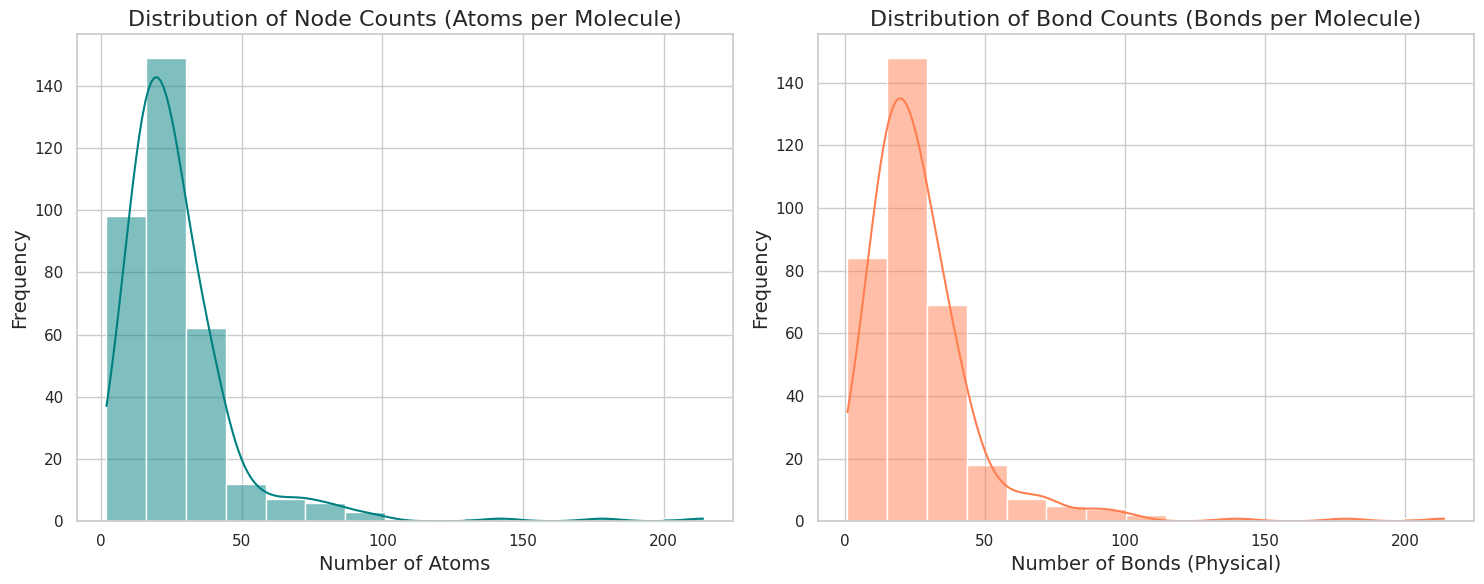

In [8]:
num_nodes = [data.num_nodes for data in pyg_dataset]
# Since edges are stored in bidirectional format, divide by 2 for physical bonds
num_bonds = [data.num_edges // 2 for data in pyg_dataset]

graph_stats_df = pd.DataFrame({
    "Nodes (Atoms)": num_nodes,
    "Bonds (Edges)": num_bonds
})

print("==================================================")
print("            MOLECULE GRAPH STATISTICS             ")
print("==================================================")
print(graph_stats_df.describe().round(2))
print("==================================================")

# Plot Node and Edge Distributions side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(ax=axes[0], data=graph_stats_df, x="Nodes (Atoms)", kde=True, color="teal", bins=15)
axes[0].set_title("Distribution of Node Counts (Atoms per Molecule)")
axes[0].set_xlabel("Number of Atoms")
axes[0].set_ylabel("Frequency")

sns.histplot(ax=axes[1], data=graph_stats_df, x="Bonds (Edges)", kde=True, color="coral", bins=15)
axes[1].set_title("Distribution of Bond Counts (Bonds per Molecule)")
axes[1].set_xlabel("Number of Bonds (Physical)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


 ### 2.2 Atom and Bond Type Distributions

 We analyze the frequency of various atom types and bond/relation types inside the preprocessed PyG graphs.

 The node feature matrix `x` is one-hot encoded, but we can reconstruct the actual categories from metadata.

Total atom occurrences in dataset: 9189
Total bond occurrences in dataset: 9317

Top 15 Atom Types by Frequency:
  Atom Type  Count  Percentage
 Hydrogen-3   3632   39.525520
  Carbon-22   1841   20.034824
  Carbon-10   1162   12.645554
 Hydrogen-1    355    3.863315
Chlorine-93    281    3.058004
  Oxygen-40    246    2.677114
Nitrogen-32    242    2.633584
  Carbon-14    170    1.850038
  Oxygen-45    159    1.730330
  Oxygen-50    131    1.425618
  Carbon-16    115    1.251496
 Hydrogen-8    112    1.218849
  Oxygen-49    100    1.088258
  Oxygen-51     74    0.805311
  Carbon-27     55    0.598542

Bond Types by Frequency:
Bond Type  Count  Percentage
   Bond-1   6781   72.780938
   Bond-7   2067   22.185253
   Bond-2    463    4.969411
   Bond-3      6    0.064398


/tmp/ipykernel_217838/3439910852.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=atom_counts_df.head(15), x="Count", y="Atom Type", palette="crest")
/tmp/ipykernel_217838/3439910852.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=bond_counts_df, x="Count", y="Bond Type", palette="flare")


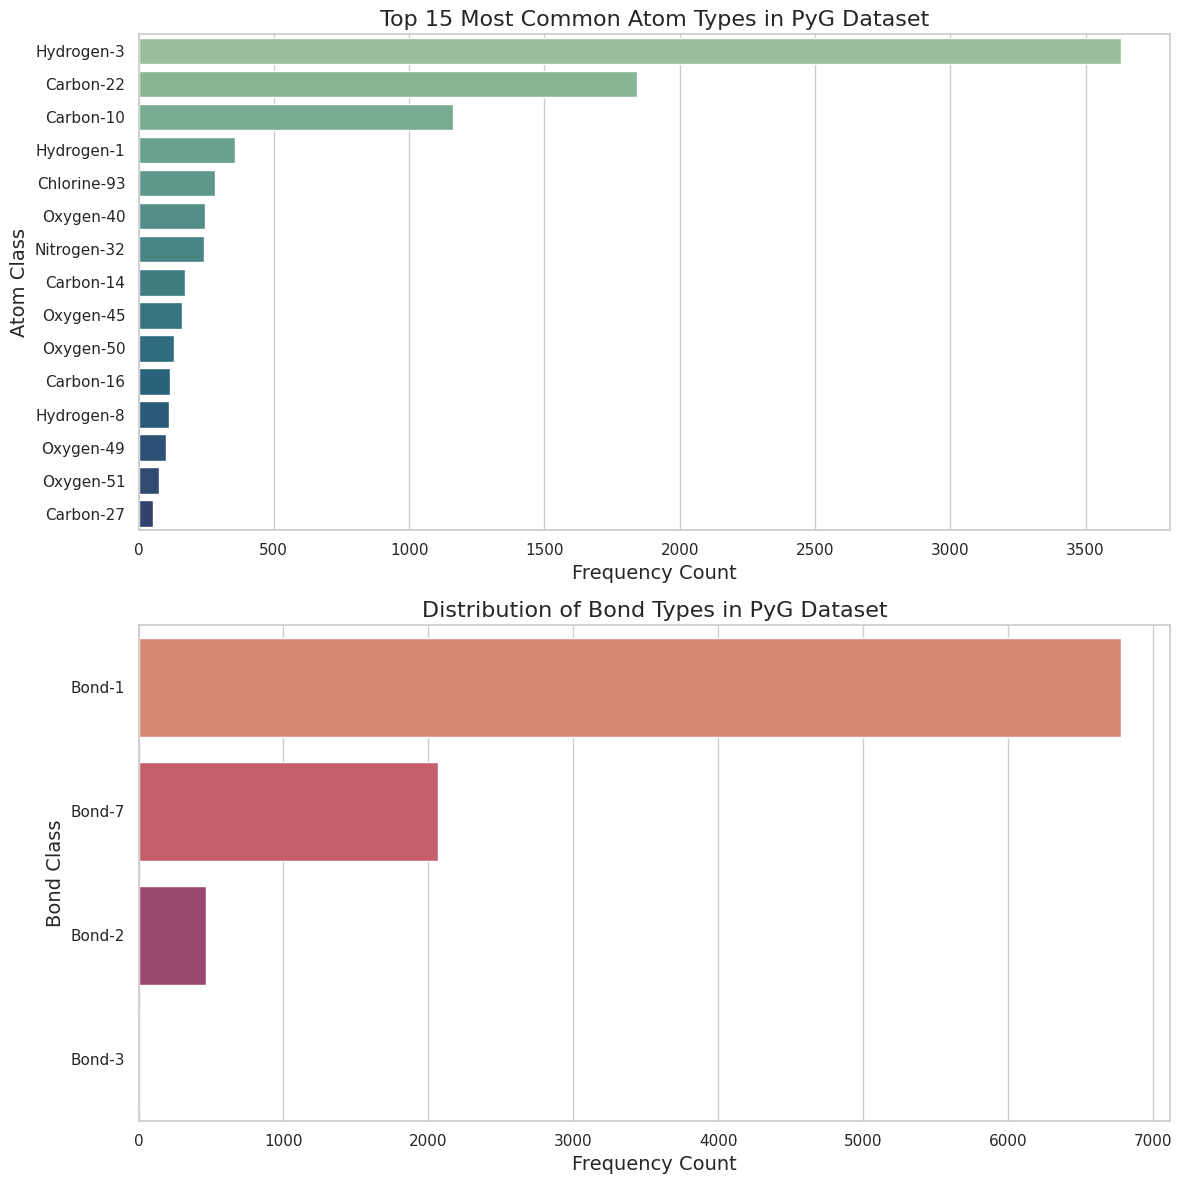

In [9]:
# Extract all atom types and bonds
all_atoms = []
all_bonds = []

for data in pyg_dataset:
    for atom in data.atom_info:
        all_atoms.append(atom["type"])
    for src, dst, bond_type in data.bond_info:
        all_bonds.append(bond_type)

atom_counts = Counter(all_atoms)
bond_counts = Counter(all_bonds)

print(f"Total atom occurrences in dataset: {len(all_atoms)}")
print(f"Total bond occurrences in dataset: {len(all_bonds)}")

# Top atom types
atom_counts_df = pd.DataFrame(atom_counts.most_common(), columns=["Atom Type", "Count"])
atom_counts_df["Percentage"] = (atom_counts_df["Count"] / len(all_atoms)) * 100

print("\nTop 15 Atom Types by Frequency:")
print(atom_counts_df.head(15).to_string(index=False))

# Bond types
bond_counts_df = pd.DataFrame(bond_counts.most_common(), columns=["Bond Type", "Count"])
bond_counts_df["Percentage"] = (bond_counts_df["Count"] / len(all_bonds)) * 100

print("\nBond Types by Frequency:")
print(bond_counts_df.to_string(index=False))

# Plot top atom and bond types
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

sns.barplot(ax=axes[0], data=atom_counts_df.head(15), x="Count", y="Atom Type", palette="crest")
axes[0].set_title("Top 15 Most Common Atom Types in PyG Dataset")
axes[0].set_xlabel("Frequency Count")
axes[0].set_ylabel("Atom Class")

sns.barplot(ax=axes[1], data=bond_counts_df, x="Count", y="Bond Type", palette="flare")
axes[1].set_title("Distribution of Bond Types in PyG Dataset")
axes[1].set_xlabel("Frequency Count")
axes[1].set_ylabel("Bond Class")

plt.tight_layout()
plt.show()


 ### 2.3 Graph Properties: Degree and Density Analysis

 The node degree represents the number of chemical bonds connected to an atom.

 Let's compute average node degrees, density, and connectivity for each graph.

            TOPOLOGICAL GRAPH ANALYSIS            
Average Node Degree across dataset : 1.98
Average Graph Density              : 0.122
Percentage of Connected Graphs     : 96.2%


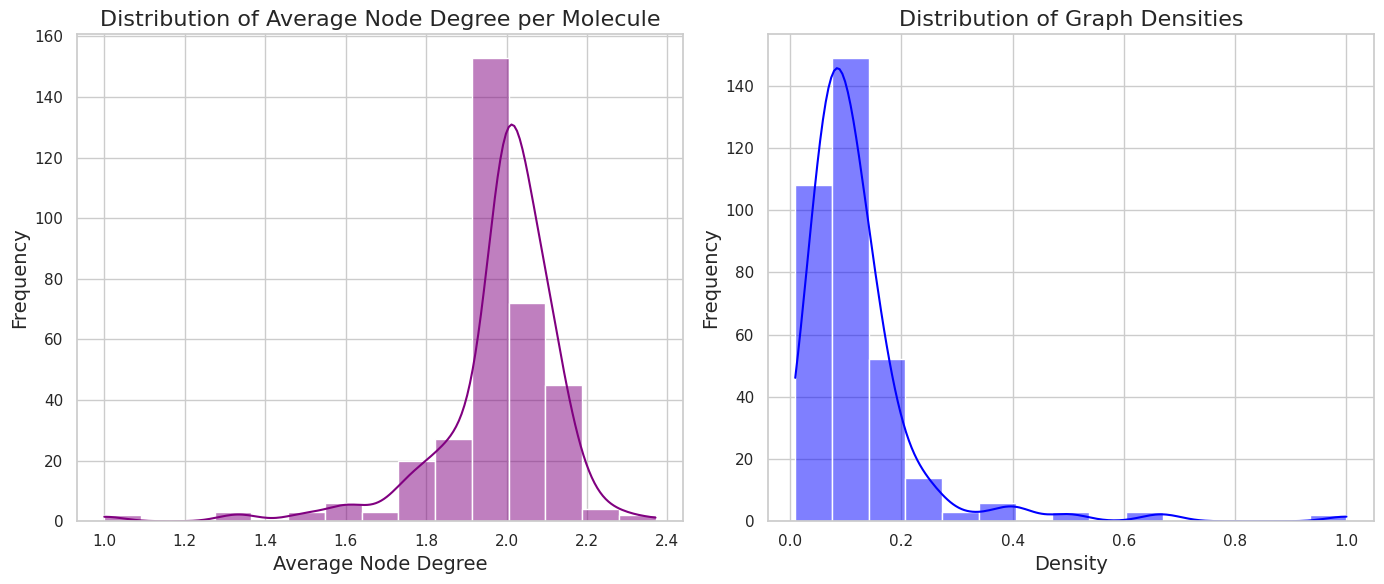

In [10]:
avg_degrees = []
graph_densities = []
is_connected_list = []

for data in pyg_dataset:
    # Build NetworkX graph to analyze topology
    edges = data.edge_index.t().tolist()
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(edges)
    
    # Compute degree
    degrees = [d for n, d in g.degree()]
    avg_degrees.append(np.mean(degrees))
    
    # Compute density
    graph_densities.append(nx.density(g))
    
    # Check if connected
    is_connected_list.append(nx.is_connected(g))

print("==================================================")
print("            TOPOLOGICAL GRAPH ANALYSIS            ")
print("==================================================")
print(f"Average Node Degree across dataset : {np.mean(avg_degrees):.2f}")
print(f"Average Graph Density              : {np.mean(graph_densities):.3f}")
print(f"Percentage of Connected Graphs     : {np.mean(is_connected_list)*100:.1f}%")
print("==================================================")

# Plot Average Degree and Density Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(ax=axes[0], x=avg_degrees, kde=True, color="purple", bins=15)
axes[0].set_title("Distribution of Average Node Degree per Molecule")
axes[0].set_xlabel("Average Node Degree")
axes[0].set_ylabel("Frequency")

sns.histplot(ax=axes[1], x=graph_densities, kde=True, color="blue", bins=15)
axes[1].set_title("Distribution of Graph Densities")
axes[1].set_xlabel("Density")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


 ### 2.4 Chemical Cycles and Ring Structure Analysis

 In chemistry, ring structures (like benzene) are key components of chemical compounds.

 Let's extract the cycle basis for each molecule and examine how the number of cycles and presence of 6-membered rings correlates with mutagenicity.

            CYCLE & RING ANALYSIS STATS           
Average Rings (Mutagenic)           : 1.845
Average Rings (Non-Mutagenic)       : 1.161
Average 6-Membered Rings (Mutagenic): 1.287
Average 6-Membered Rings (Non-Mutag): 1.081


/tmp/ipykernel_217838/3559717151.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], data=cycle_data, x="Class", y="Total Rings", palette=["#e74c3c", "#2ecc71"])
/tmp/ipykernel_217838/3559717151.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(ax=axes[1], data=cycle_data, x="Class", y="6-Membered Rings", ci=None, palette=["#e74c3c", "#2ecc71"])
/tmp/ipykernel_217838/3559717151.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=cycle_data, x="Class", y="6-Membered Rings", ci=None, palette=["#e74c3c", "#2ecc71"])


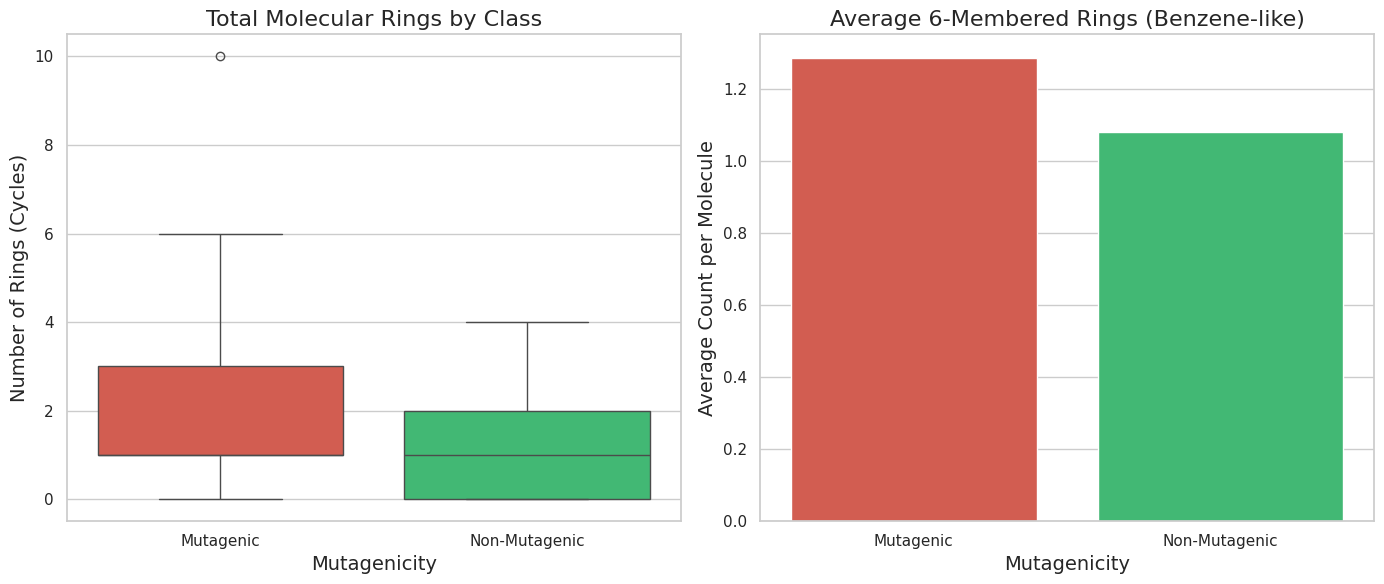

In [11]:
mutagenic_rings = []
non_mutagenic_rings = []
mutagenic_six_rings = []
non_mutagenic_six_rings = []

for data in pyg_dataset:
    edges = data.edge_index.t().tolist()
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(edges)
    
    # Calculate cycle basis
    cb = nx.cycle_basis(g)
    num_rings = len(cb)
    num_six_rings = sum(1 for c in cb if len(c) == 6)
    
    if data.y.item() == 1:
        mutagenic_rings.append(num_rings)
        mutagenic_six_rings.append(num_six_rings)
    else:
        non_mutagenic_rings.append(num_rings)
        non_mutagenic_six_rings.append(num_six_rings)

print("==================================================")
print("            CYCLE & RING ANALYSIS STATS           ")
print("==================================================")
print(f"Average Rings (Mutagenic)           : {np.mean(mutagenic_rings):.3f}")
print(f"Average Rings (Non-Mutagenic)       : {np.mean(non_mutagenic_rings):.3f}")
print(f"Average 6-Membered Rings (Mutagenic): {np.mean(mutagenic_six_rings):.3f}")
print(f"Average 6-Membered Rings (Non-Mutag): {np.mean(non_mutagenic_six_rings):.3f}")
print("==================================================")

# Visualize comparison of cycle metrics by category
cycle_data = pd.DataFrame({
    "Class": ["Mutagenic"] * len(mutagenic_rings) + ["Non-Mutagenic"] * len(non_mutagenic_rings),
    "Total Rings": mutagenic_rings + non_mutagenic_rings,
    "6-Membered Rings": mutagenic_six_rings + non_mutagenic_six_rings
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(ax=axes[0], data=cycle_data, x="Class", y="Total Rings", palette=["#e74c3c", "#2ecc71"])
axes[0].set_title("Total Molecular Rings by Class")
axes[0].set_ylabel("Number of Rings (Cycles)")
axes[0].set_xlabel("Mutagenicity")

sns.barplot(ax=axes[1], data=cycle_data, x="Class", y="6-Membered Rings", ci=None, palette=["#e74c3c", "#2ecc71"])
axes[1].set_title("Average 6-Membered Rings (Benzene-like)")
axes[1].set_ylabel("Average Count per Molecule")
axes[1].set_xlabel("Mutagenicity")

plt.tight_layout()
plt.show()


 ### 2.5 Beautiful Molecule Visualizations

 We select two molecule graphs:

 1. One **Mutagenic** molecule (Label 1)

 2. One **Non-Mutagenic** molecule (Label 0)



 We map their atoms to CPK chemical colors and draw them using NetworkX with Force-Directed layouts.

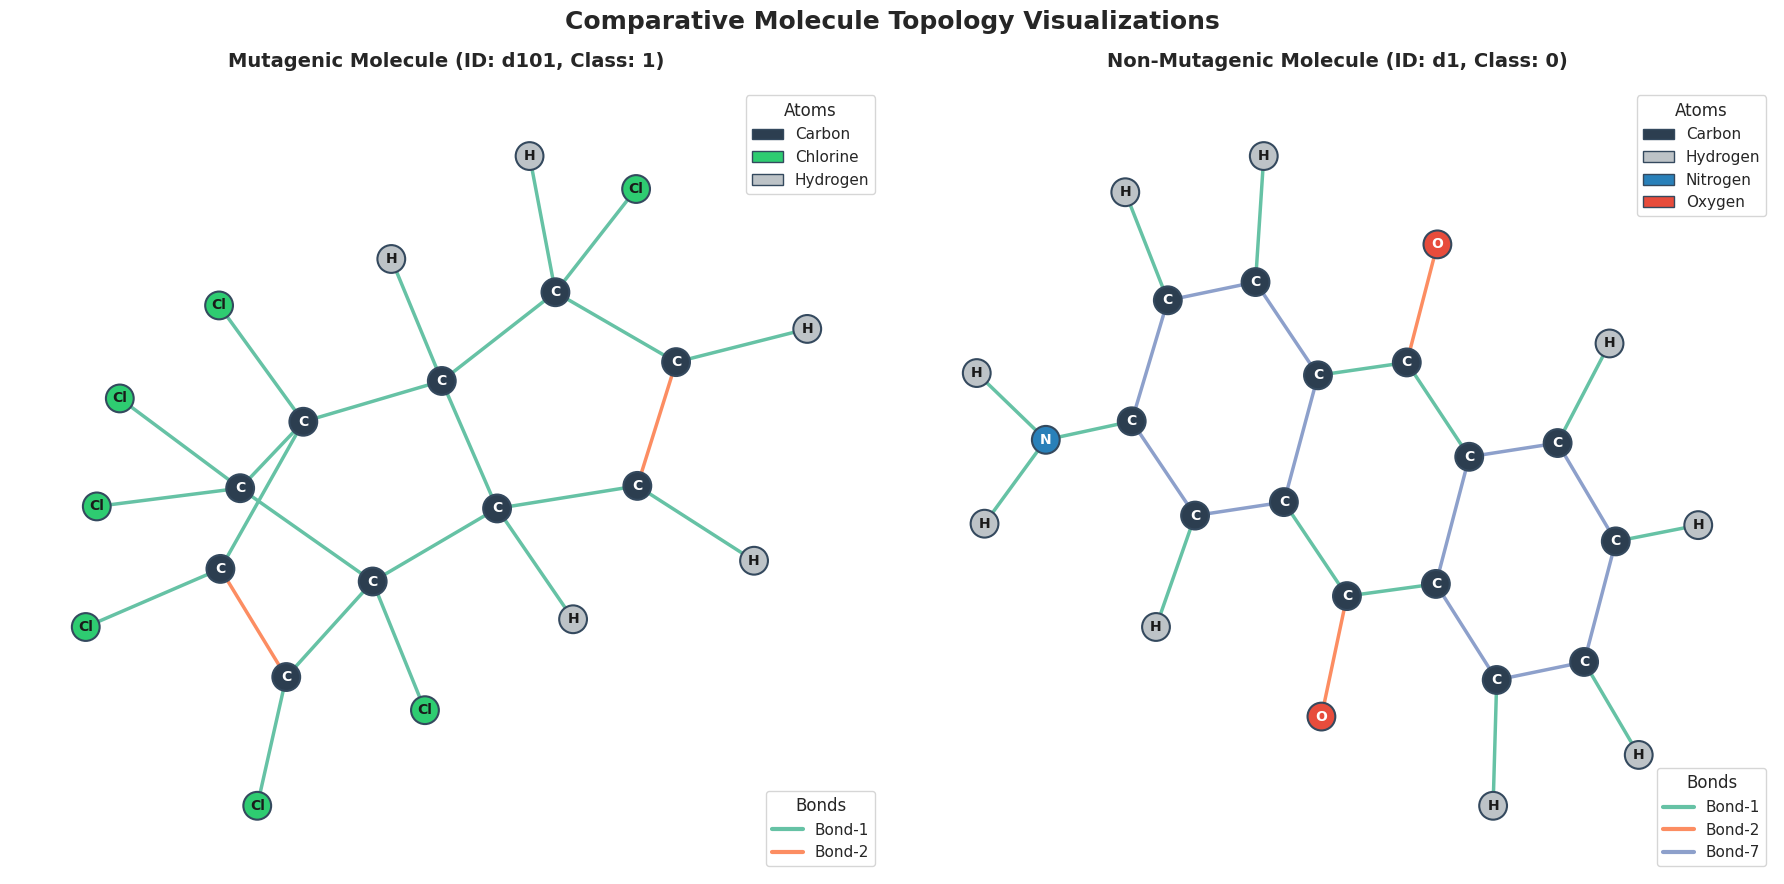

In [12]:
def visualize_molecule(data, ax, title):
    # Create undirected networkx graph
    edges = data.edge_index.t().tolist()
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(edges)
    
    # Extract element prefixes for node coloring
    atom_elements = [atom["type"].split("-")[0] for atom in data.atom_info]
    
    # Standard CPK element colors for chemistry
    cpk_colors = {
        'Carbon': '#2c3e50',      # Dark Slate Grey
        'Hydrogen': '#bdc3c7',    # Silver/White
        'Nitrogen': '#2980b9',    # Blue
        'Oxygen': '#e74c3c',      # Red
        'Chlorine': '#2ecc71',    # Green
        'Bromine': '#d35400',     # Brown/Orange
        'Fluorine': '#1abc9c',    # Turquoise
        'Sulfur': '#f1c40f',      # Yellow
        'Phosphorus': '#e67e22',  # Orange
        'Iodine': '#8e44ad',      # Purple
        'Sodium': '#f39c12',      # Amber
    }
    
    # Map nodes to colors
    node_colors = [cpk_colors.get(elem, '#7f8c8d') for elem in atom_elements]
    
    # Node labels: Element first letter (e.g. C, H, N, O)
    element_symbols = {
        'Carbon': 'C', 'Hydrogen': 'H', 'Nitrogen': 'N', 'Oxygen': 'O',
        'Chlorine': 'Cl', 'Bromine': 'Br', 'Fluorine': 'F', 'Sulfur': 'S',
        'Phosphorus': 'P', 'Iodine': 'I', 'Sodium': 'Na'
    }
    labels = {i: element_symbols.get(elem, elem[:2]) for i, elem in enumerate(atom_elements)}
    
    # Bond type coloring
    unique_bonds = sorted(list({b[2] for b in data.bond_info}))
    bond_colors_palette = sns.color_palette("Set2", max(len(unique_bonds), 1))
    bond_types = {name: idx for idx, name in enumerate(unique_bonds)}
    
    # Map edges to bond colors
    edge_colors = []
    bond_lookup = {}
    for src, dst, bond_name in data.bond_info:
        bond_lookup[(src, dst)] = bond_name
        bond_lookup[(dst, src)] = bond_name
        
    for u, v in g.edges():
        b_name = bond_lookup.get((u, v), unique_bonds[0] if unique_bonds else 'Bond-1')
        color_idx = bond_types.get(b_name, 0)
        edge_colors.append(bond_colors_palette[color_idx])
        
    # Draw layout (Kamada-Kawai algorithm generates organic, molecule-like layouts)
    pos = nx.kamada_kawai_layout(g)
    
    # Draw nodes and edges
    nx.draw_networkx_nodes(g, pos, node_color=node_colors, node_size=400, edgecolors='#34495e', linewidths=1.5, ax=ax)
    nx.draw_networkx_edges(g, pos, edge_color=edge_colors, width=2.5, ax=ax)
    
    # Draw labels with high-contrast text color based on node type
    for i, elem in enumerate(atom_elements):
        text_color = 'white' if elem in ['Carbon', 'Nitrogen', 'Oxygen', 'Iodine'] else '#1a1a1a'
        nx.draw_networkx_labels(g, pos, labels={i: labels[i]}, font_size=10, font_weight='bold', font_color=text_color, ax=ax)
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.axis('off')
    
    # Legends for elements (nodes)
    unique_elements = sorted(list(set(atom_elements)))
    legend_elements = [Patch(facecolor=cpk_colors.get(el, '#7f8c8d'), edgecolor='#34495e', label=el) for el in unique_elements]
    
    # Legends for bond types (edges)
    bond_legend_elements = [
        Line2D([0], [0], color=bond_colors_palette[idx], lw=3, label=b_name)
        for b_name, idx in bond_types.items()
    ]
    
    legend1 = ax.legend(handles=legend_elements, loc='upper right', framealpha=0.8, title="Atoms")
    ax.add_artist(legend1)
    ax.legend(handles=bond_legend_elements, loc='lower right', framealpha=0.8, title="Bonds")

# Filter mutagenic and non-mutagenic graphs
mutagenic_mols = [d for d in pyg_dataset if d.y.item() == 1]
non_mutagenic_mols = [d for d in pyg_dataset if d.y.item() == 0]

# Pick a representative molecule for each class
mol_mut = mutagenic_mols[0]
mol_non_mut = non_mutagenic_mols[0]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

visualize_molecule(mol_mut, axes[0], f"Mutagenic Molecule (ID: {mol_mut.molecule_id}, Class: 1)")
visualize_molecule(mol_non_mut, axes[1], f"Non-Mutagenic Molecule (ID: {mol_non_mut.molecule_id}, Class: 0)")

plt.suptitle("Comparative Molecule Topology Visualizations", y=0.98, weight='bold')
plt.tight_layout()
plt.show()
